#📌 Extracão

In [ ]:
import pandas as pd

url = 'https://raw.githubusercontent.com/alura-cursos/challenge2-data-science/refs/heads/main/TelecomX_Data.json'

df = pd.read_json(url)

In [ ]:
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [ ]:
# Normaliza cada coluna que contém dicionários

df_customer = pd.json_normalize(df['customer'])
df_phone = pd.json_normalize(df['phone'])
df_internet = pd.json_normalize(df['internet'])
df_account = pd.json_normalize(df['account'])

# Isola as colunas que já estavam normais
df_base = df[['customerID', 'Churn']]

# Junta tudo em um único DataFrame
df = pd.concat([df_base, df_customer, df_phone, df_internet, df_account], axis=1)

In [ ]:
df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


#🔧 Transformação

In [ ]:
#Explorando as colunas do dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


Percebemos que a coluna Charges.Total (Cobrança Total), que deveria ser um valor numérico, está definida como texto.

In [ ]:
# Vamos ordenar os valores para tentar encontrar inconsistências

df['Charges.Total'].sort_values()

,Charges.Total
1955,
2930,
1775,
4169,
2308,
...,...
4422,998.1
4411,999.45
4291,999.45
3250,999.8


In [ ]:
# Analisando quantas linhas possuem o Charges.Total vazio

df[df['Charges.Total'] == ' ']

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
975,1371-DWPAZ,No,Female,0,Yes,Yes,0,No,No phone service,DSL,...,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,
1775,2520-SGTTA,No,Female,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,
1955,2775-SEFEE,No,Male,0,No,Yes,0,Yes,Yes,DSL,...,Yes,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),61.90,
2075,2923-ARZLG,No,Male,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,
2232,3115-CZMZD,No,Male,0,No,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,
2308,3213-VVOLG,No,Male,0,Yes,Yes,0,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,
2930,4075-WKNIU,No,Female,0,Yes,Yes,0,Yes,Yes,DSL,...,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,
3134,4367-NUYAO,No,Male,0,Yes,Yes,0,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,
3203,4472-LVYGI,No,Female,0,Yes,Yes,0,No,No phone service,DSL,...,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,
4169,5709-LVOEQ,No,Female,0,Yes,Yes,0,Yes,No,DSL,...,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,


- Notamos que a coluna Charges.Total possui 11 valores em branco
- Notamos que são clientes novatos (onde o tenure/meses de contrato é 0) e que ainda não tiveram sua primeira cobrança totalizada.
- Estes valores deverão ser definidos como NaN para a coluna ser convertida para numérica
- Os valores em branco serão preenchidos com o número zero

In [ ]:
# Convertendo a coluna para numérica

df['Charges.Total'] = pd.to_numeric(df['Charges.Total'], errors='coerce')

# Preenchendo os valores em branco com 0

df['Charges.Total'] = df['Charges.Total'].fillna(0)

In [ ]:
# Verificação que a coluna está como numérica

df['Charges.Total'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 7267 entries, 0 to 7266
Series name: Charges.Total
Non-Null Count  Dtype  
--------------  -----  
7267 non-null   float64
dtypes: float64(1)
memory usage: 56.9 KB


Algumas colunas categóricas têm classes que dizem praticamente a mesma coisa.
Na coluna MultipleLines, temos as categorias:

`['No', 'Yes', 'No phone service']`

Nas colunas de serviços de internet (como OnlineSecurity, TechSupport, StreamingTV, etc.), temos:

`['No', 'Yes', 'No internet service']`

"No internet service" e "No phone service" significam, na prática, que o cliente Não (No) possui aquele serviço específico. Para facilitar futuras análises vamos substituir essas descrições longas por um simples "No", deixando essas colunas apenas como Yes ou No.

In [ ]:
colunas_internet = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                    'TechSupport', 'StreamingTV', 'StreamingMovies']

for coluna in colunas_internet:
    df[coluna] = df[coluna].replace('No internet service', 'No')

df['MultipleLines'] = df['MultipleLines'].replace('No phone service', 'No')

Fazendo uma verificação nos valores únicos da coluna 'Churn' verificamos que há valores em branco

In [ ]:
#Verificação de valores únicos na coluna Churn

df['Churn'].unique()

array(['No', 'Yes', ''], dtype=object)

In [ ]:
# Analisando a quantidade de valores em branco na coluna Churn

df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869
,224


Como o Churn é a nossa "variável alvo" (o que queremos prever ou analisar), não podemos ter clientes sem essa informação. Vamos fazer um filtro na coluna para remover essas 224 linhas, pois esses valores podem enviesar nossa análise.

In [ ]:
# Filtrando os dados para remover as colunas onde churn é vazio

df = df[df['Churn'] != '']
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


- Vamos criar a coluna de Contas_Diarias
- Basta dividir a coluna de Charges.Monthly (Contas mensais) por 30

In [ ]:
df['Contas_Diarias'] = round(df['Charges.Monthly']/30 , 2)

Vamos traduzir as colunas para dar uma clareza e melhor acessibilidade para quem estiver lendo.

In [ ]:
traducao_colunas = {
    'customerID': 'ID_Cliente',
    'Churn': 'Churn', # Mantemos Churn pois é o termo padrão no mercado
    'gender': 'Genero',
    'SeniorCitizen': 'Idoso',
    'Partner': 'Possui_Parceiro',
    'Dependents': 'Possui_Dependentes',
    'tenure': 'Meses_Contrato',
    'PhoneService': 'Servico_Telefone',
    'MultipleLines': 'Multiplas_Linhas',
    'InternetService': 'Servico_Internet',
    'OnlineSecurity': 'Seguranca_Online',
    'OnlineBackup': 'Backup_Online',
    'DeviceProtection': 'Protecao_Dispositivo',
    'TechSupport': 'Suporte_Tecnico',
    'StreamingTV': 'Streaming_TV',
    'StreamingMovies': 'Streaming_Filmes',
    'Contract': 'Tipo_Contrato',
    'PaperlessBilling': 'Fatura_Digital',
    'PaymentMethod': 'Metodo_Pagamento',
    'Charges.Monthly': 'Cobranca_Mensal',
    'Charges.Total': 'Cobranca_Total',
    'Contas_Diarias': 'Cobranca_Diaria'
}

df = df.rename(columns = traducao_colunas)

In [ ]:
df.head(2)

,ID_Cliente,Churn,Genero,Idoso,Possui_Parceiro,Possui_Dependentes,Meses_Contrato,Servico_Telefone,Multiplas_Linhas,Servico_Internet,...,Protecao_Dispositivo,Suporte_Tecnico,Streaming_TV,Streaming_Filmes,Tipo_Contrato,Fatura_Digital,Metodo_Pagamento,Cobranca_Mensal,Cobranca_Total,Cobranca_Diaria
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3,2.19
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4,2.00


Vamos converter as colunas que posuuem somente valores 'Yes' e 'No' para 1 e 0, respectivamente.

In [ ]:
colunas_sim_nao = [
    'Churn',
    'Possui_Parceiro',
    'Possui_Dependentes',
    'Servico_Telefone',
    'Multiplas_Linhas',
    'Seguranca_Online',
    'Backup_Online',
    'Protecao_Dispositivo',
    'Suporte_Tecnico',
    'Streaming_TV',
    'Streaming_Filmes',
    'Fatura_Digital',
]

for coluna in colunas_sim_nao:
  df[coluna] = df[coluna].replace('Yes',1)
  df[coluna] = df[coluna].replace('No',0)

/tmp/ipykernel_1123/3245933885.py:18: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[coluna] = df[coluna].replace('No',0)


In [ ]:
df.head()

,ID_Cliente,Churn,Genero,Idoso,Possui_Parceiro,Possui_Dependentes,Meses_Contrato,Servico_Telefone,Multiplas_Linhas,Servico_Internet,...,Protecao_Dispositivo,Suporte_Tecnico,Streaming_TV,Streaming_Filmes,Tipo_Contrato,Fatura_Digital,Metodo_Pagamento,Cobranca_Mensal,Cobranca_Total,Cobranca_Diaria
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,1,Male,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,1,Male,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,1,Female,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.80


#📊 Carga e análise

## Resumo estatístico das variáveis

In [ ]:
# Resumo estatístico das variáveis categóricas

resumo_categorico = df.describe(include=['object'])
display(resumo_categorico)

,ID_Cliente,Genero,Servico_Internet,Tipo_Contrato,Metodo_Pagamento
count,7043,7043,7043,7043,7043
unique,7043,2,3,3,4
top,9995-HOTOH,Male,Fiber optic,Month-to-month,Electronic check
freq,1,3555,3096,3875,2365


- Tipo de Contrato: O contrato mais comum (Top da categoria texto) é o "Month-to-month" (Mês a Mês), com 3.875 clientes utilizando esse formato (55%). Esse é um ponto de atenção fortíssimo para evasão!

- Internet: A tecnologia "Fiber optic" (Fibra ótica) é o serviço de internet mais comum na base (3.096 assinantes ou 44%).

In [ ]:
# Resumo estatístico das variáveis numéricas

resumo_numerico = df.describe().round(2)
display(resumo_numerico)

,Churn,Idoso,Possui_Parceiro,Possui_Dependentes,Meses_Contrato,Servico_Telefone,Multiplas_Linhas,Seguranca_Online,Backup_Online,Protecao_Dispositivo,Suporte_Tecnico,Streaming_TV,Streaming_Filmes,Fatura_Digital,Cobranca_Mensal,Cobranca_Total,Cobranca_Diaria
count,7043.00,7043.00,7043.00,7043.00,7043.00,7043.0,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00
mean,0.27,0.16,0.48,0.30,32.37,0.9,0.42,0.29,0.34,0.34,0.29,0.38,0.39,0.59,64.76,2279.73,2.16
std,0.44,0.37,0.50,0.46,24.56,0.3,0.49,0.45,0.48,0.48,0.45,0.49,0.49,0.49,30.09,2266.79,1.00
min,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,18.25,0.00,0.61
25%,0.00,0.00,0.00,0.00,9.00,1.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,35.50,398.55,1.18
50%,0.00,0.00,0.00,0.00,29.00,1.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,70.35,1394.55,2.34
75%,1.00,0.00,1.00,1.00,55.00,1.0,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,89.85,3786.60,2.99
max,1.00,1.00,1.00,1.00,72.00,1.0,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,118.75,8684.80,3.96


- Taxa de Cancelamento: Como transformamos o Churn em 1 e 0, a média (mean) de 0.27 nos diz que 27% dos clientes cancelaram seus serviços. Esta é uma taxa relativamente alta.

- Cobrança Mensal (Cobranca_Mensal): A média que o cliente paga por mês é de 64.76. No entanto, metade dos clientes (a mediana, ou o percentil 50%) paga 70.35 ou menos. O cliente que mais paga desembolsa $118.75 ao mês.

- Cobrança Diária (Cobranca_Diaria): O custo médio por dia de um cliente é de 2.16. O valor máximo diário chega a $3.96.

- Custo Total (Cobranca_Total): A média do valor total já pago pelos clientes (Lifetime Value) é muito afetada pelos clientes antigos vs novos. O valor médio é de 2279.73, enquanto o desvio padrão (std) é gigante (2266.79). Isso mostra uma extrema variação: temos clientes novatos (mínimo de 0) até clientes fiéis que já geraram $8684.80 de receita.

- Meses de Contrato (Meses_Contrato): Os clientes ficam, em média, 32 meses na empresa. A mediana é de 29 meses. O cliente mais antigo está a 72 meses (6 anos).

- Idosos e Dependentes: Apenas 16% da base é composta por idosos. Cerca de 30% têm dependentes.

- Serviços Populares vs. Baixa Adesão: Praticamente todo mundo tem serviço de telefone (90% de média). Por outro lado, o Suporte_Tecnico e a Seguranca_Online são serviços pouco adquiridos, ambos com apenas 29% de adesão.

## Distribuição da evasão

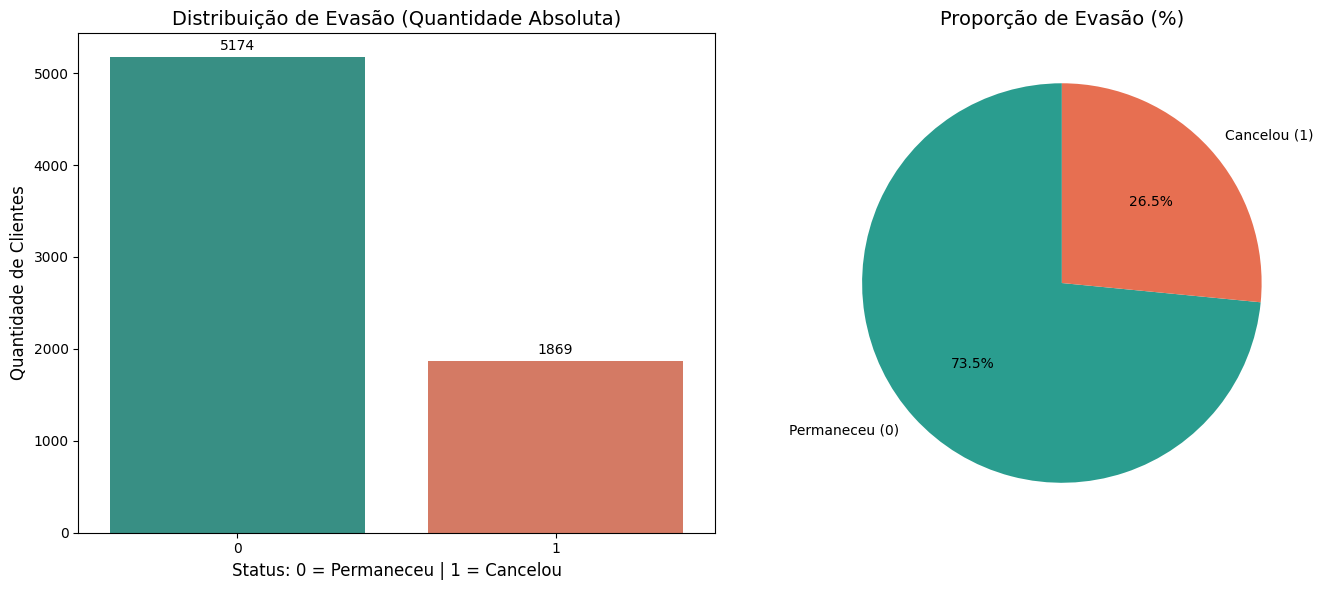

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando o tamanho da imagem (1 linha, 2 colunas)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Cores que vão facilitar a visualização (Verde para quem fica, Vermelho/Laranja para quem sai)
cores = ['#2a9d8f', '#e76f51']

# 1. Gráfico de Barras (Contagem Absoluta)
sns.countplot(data=df, x='Churn', ax=ax1, palette=cores, order=[0, 1], hue='Churn', legend=False)
ax1.set_title('Distribuição de Evasão (Quantidade Absoluta)', fontsize=14)
ax1.set_xlabel('Status: 0 = Permaneceu | 1 = Cancelou', fontsize=12)
ax1.set_ylabel('Quantidade de Clientes', fontsize=12)

# Colocando os números em cima das barras para facilitar a leitura
for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height())}',
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 8), textcoords='offset points')

# 2. Gráfico de Pizza (Proporção Percentual)
contagem = df['Churn'].value_counts()
labels = ['Permaneceu (0)', 'Cancelou (1)']
ax2.pie(contagem, labels=labels, autopct='%1.1f%%', startangle=90, colors=cores)
ax2.set_title('Proporção de Evasão (%)', fontsize=14)

# Ajusta os espaçamentos e exibe os gráficos
plt.tight_layout()
plt.show()

- Dos 7.043 clientes analisados, 5.174 permaneceram (73,5%), enquanto 1.869 cancelaram o serviço (26,5%).
- Tamanho do Problema: A Telecom X perde mais de um quarto (26,5%) de todos os seus clientes. Esse é um indício de que alguma etapa da jornada do cliente precisa de melhorias urgentes.

## Contagem de Evasão por Variáveis Categóricas

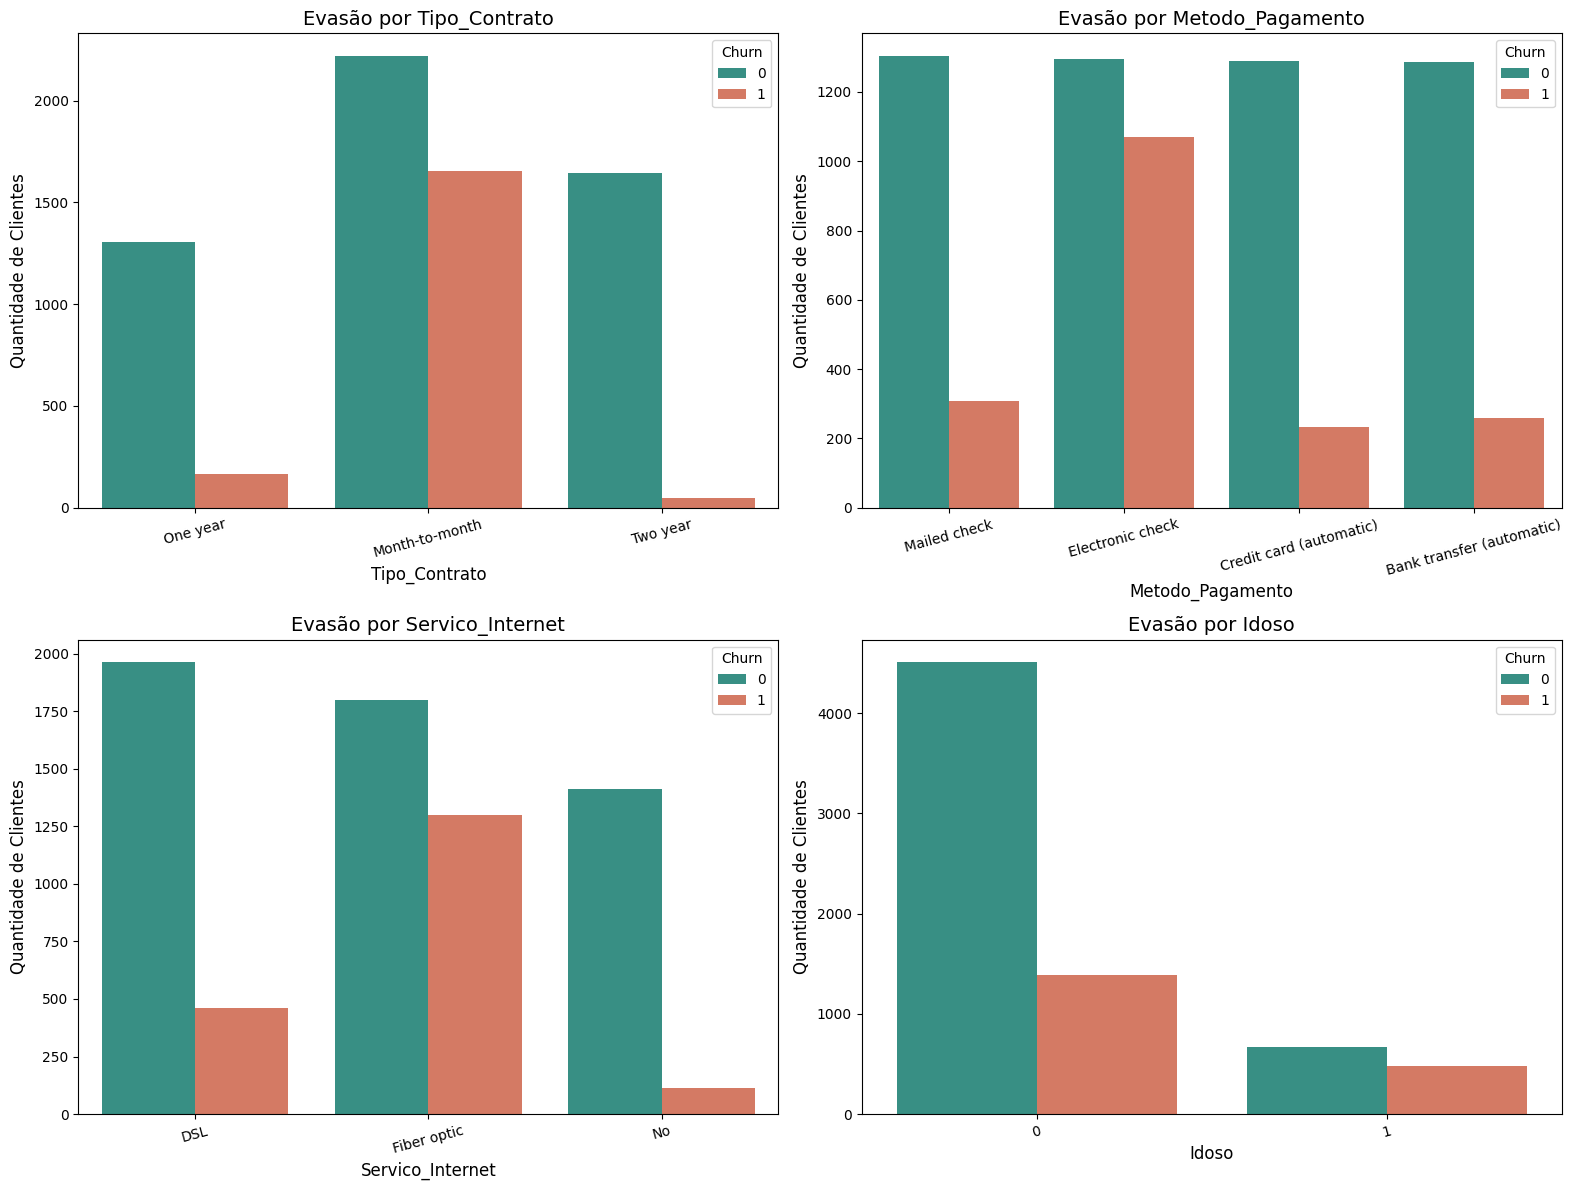


--- Taxa de Evasão (%): Tipo_Contrato ---
Tipo_Contrato
Month-to-month    42.71
One year          11.27
Two year           2.83
Name: Churn, dtype: float64

--- Taxa de Evasão (%): Metodo_Pagamento ---
Metodo_Pagamento
Bank transfer (automatic)    16.71
Credit card (automatic)      15.24
Electronic check             45.29
Mailed check                 19.11
Name: Churn, dtype: float64

--- Taxa de Evasão (%): Servico_Internet ---
Servico_Internet
DSL            18.96
Fiber optic    41.89
No              7.40
Name: Churn, dtype: float64

--- Taxa de Evasão (%): Idoso ---
Idoso
0    23.61
1    41.68
Name: Churn, dtype: float64


In [ ]:
# 1. Escolhendo as colunas que queremos analisar
colunas_analise = ['Tipo_Contrato', 'Metodo_Pagamento', 'Servico_Internet', 'Idoso']

# 2. Configurando o grid da imagem (2 linhas, 2 colunas = 4 gráficos)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Achata (flatten) a matriz de eixos para facilitar o loop
axes = axes.flatten()

# Cores para Padronizar (0 = Verde/Fica, 1 = Vermelho/Sai)
cores = ['#2a9d8f', '#e76f51']

# 3. Loop para criar cada um dos gráficos
for i, coluna in enumerate(colunas_analise):
    sns.countplot(data=df, x=coluna, hue='Churn', ax=axes[i], palette=cores)

    # Adicionando título e ajustando as legendas dos eixos
    axes[i].set_title(f'Evasão por {coluna}', fontsize=14)
    axes[i].set_xlabel(coluna, fontsize=12)
    axes[i].set_ylabel('Quantidade de Clientes', fontsize=12)

    # Rotacionando os textos do eixo X (ótimo para "Metodo_Pagamento" não ficar embolado)
    axes[i].tick_params(axis='x', labelrotation=15)

# Ajuste automático dos espaços e plotagem
plt.tight_layout()
plt.show()

# 4. Código Extra: Descobrindo a Taxa Percentual de Evasão por Categoria
for coluna in colunas_analise:
    taxa = df.groupby(coluna)['Churn'].mean() * 100
    print(f"\n--- Taxa de Evasão (%): {coluna} ---")
    print(taxa.round(2))

Tipo de Contrato (O maior fator de risco):

- Clientes com contrato Mensal (Month-to-month) cancelam em uma proporção de 42,7% de evasão! Praticamente metade deles vai embora.

- Por outro lado, quem assina contrato de Dois Anos (Two year) tem uma evasão ínfima, de apenas 2,8%.

- Ação Sugerida: A Telecom X precisa criar incentivos agressivos (descontos, bônus) para migrar clientes do plano mensal para os planos anuais.

Método de Pagamento:

- Quem paga via Cheque Eletrônico (Electronic check) tem uma taxa de evasão de 45,3%, muito acima de todos os outros métodos (transferência, cartão ou cheque físico, que ficam abaixo dos 20%).

- Ação Sugerida: Investigar esse meio de pagamento! Será que há problemas na plataforma? Taxas ocultas? Ou esse método atrai clientes de maior risco financeiro?

Serviço de Internet:

- A tecnologia mais popular, a Fibra Ótica (Fiber optic), é ironicamente a que mais perde clientes: 41,9% de taxa de cancelamento. O serviço de DSL (tecnologia mais antiga e barata) perde apenas 19%.

- Ação Sugerida: A equipe técnica precisa revisar urgentemente a qualidade, a estabilidade ou o preço da Fibra Ótica. O carro-chefe da empresa está afugentando os clientes.

Perfil Demográfico (Idosos):

- Clientes idosos (Idoso = 1) cancelam quase o dobro em comparação com não idosos (41,7% contra 23,6%).

- Ação Sugerida: Pode haver uma dificuldade no uso das tecnologias oferecidas ou o preço pode estar pesando no orçamento dessa faixa etária.

## Contagem de Evasão por Variáveis Numéricas

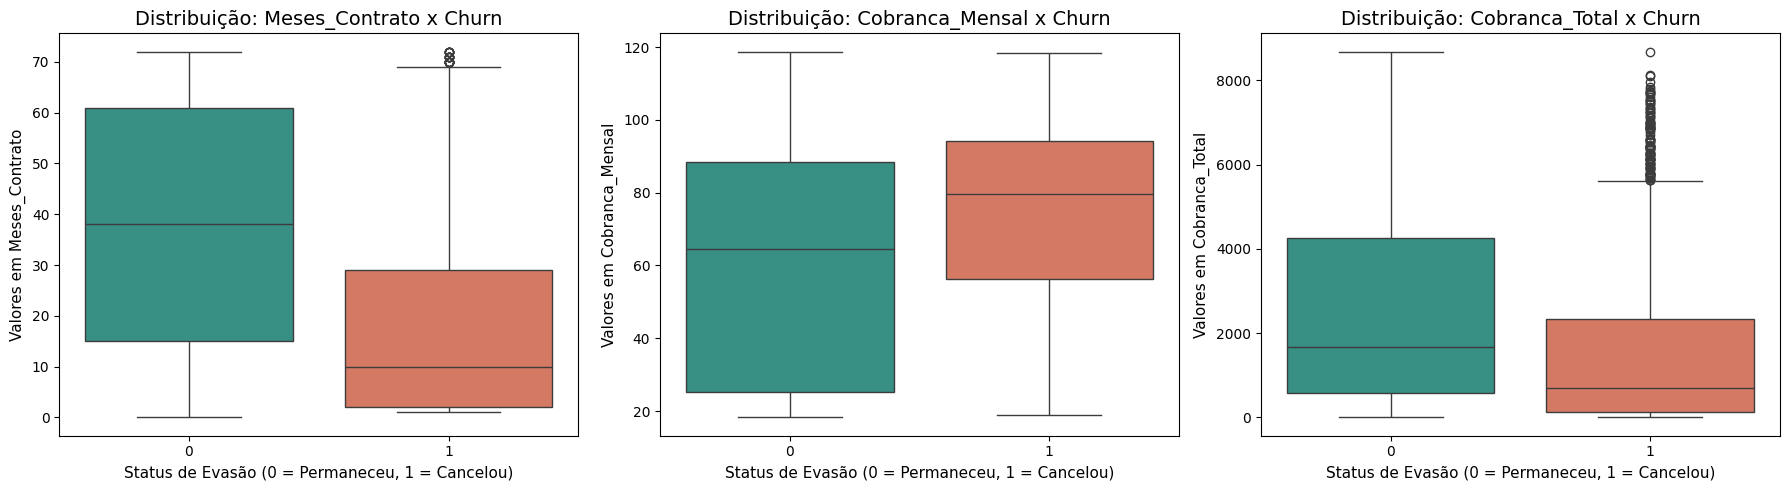


--- MEDIANA dos Valores Numéricos por Status de Evasão ---


,Meses_Contrato,Cobranca_Mensal,Cobranca_Total
Churn,,,
0,38.0,64.425,1679.525
1,10.0,79.650,703.550



--- MÉDIA dos Valores Numéricos por Status de Evasão ---


,Meses_Contrato,Cobranca_Mensal,Cobranca_Total
Churn,,,
0,37.569965,61.265124,2549.911442
1,17.979133,74.441332,1531.796094


In [ ]:
# 1. Definindo as colunas numéricas que vamos analisar
colunas_numericas = ['Meses_Contrato', 'Cobranca_Mensal', 'Cobranca_Total']

# 2. Configurando a área do gráfico (1 linha, 3 colunas de gráficos)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Cores para Padronizar: Verde (Fica) e Vermelho (Sai)
cores = ['#2a9d8f', '#e76f51']

# 3. Criando os Boxplots dinamicamente através de um loop
for i, coluna in enumerate(colunas_numericas):
    # Passando df como base de dados e garantindo a correta utilização do palette e hue
    sns.boxplot(data=df, x='Churn', y=coluna, ax=axes[i], palette=cores, hue='Churn', legend=False)

    # Adicionando títulos e labels mais legíveis
    axes[i].set_title(f'Distribuição: {coluna} x Churn', fontsize=14)
    axes[i].set_xlabel('Status de Evasão (0 = Permaneceu, 1 = Cancelou)', fontsize=11)
    axes[i].set_ylabel(f'Valores em {coluna}', fontsize=11)

# Ajuste automático e visualização
plt.tight_layout()
plt.show()

# ==============================================================
# 4. Código Extra: Olhando os números puros (Median e Mean)
# ==============================================================
print("\n--- MEDIANA dos Valores Numéricos por Status de Evasão ---")
display(df.groupby('Churn')[colunas_numericas].median())

print("\n--- MÉDIA dos Valores Numéricos por Status de Evasão ---")
display(df.groupby('Churn')[colunas_numericas].mean())

Tempo de Contrato (Meses_Contrato) - O Maior Alerta:

- Insight: Os clientes que cancelaram (Churn = 1) costumam ficar pouquíssimo tempo na empresa. A mediana (valor do meio) é de apenas 10 meses! Em contrapartida, os clientes que permanecem (Churn = 0) têm uma mediana de 38 meses (mais de 3 anos).

- Isso nos indica que os primeiros 10 a 12 meses são críticos para a retenção do cliente na Telecom X.

Cobrança Mensal (Cobranca_Mensal) - Fator Financeiro:

- Insight: Os clientes que cancelam pagam, em média, faturas consideravelmente mais caras. A mediana das faturas de quem sai é de 79.65, enquanto quem fica paga em torno de $64.42.

- Quando o preço é alto (especialmente combinado com o que vimos antes sobre Fibra Ótica e contratos mensais), a chance de evasão aumenta muito.

Cobrança Total (Cobranca_Total):

- Insight: Como os clientes que evadem ficam pouco tempo, o valor total deixado por eles na empresa é bem menor (mediana de 703.55 contra 1679.52 de quem fica).

- A Telecom X está perdendo dinheiro a longo prazo ao não conseguir reter os clientes além da barreira dos 10 meses.

# Relatório Final

📊 Relatório Final: Análise de Evasão de Clientes (Churn) - Telecom X
1. Introdução

O presente relatório documenta as etapas e descobertas do projeto de análise de dados focado no **Churn de Clientes** da empresa de telecomunicações Telecom X. O Churn (taxa de cancelamento) é uma das métricas mais críticas para empresas de serviços recorrentes, pois o custo de aquisição de um novo cliente é significativamente maior do que o custo de retenção.

**Objetivo**: Analisar a base de dados histórica da Telecom X para identificar os principais fatores e padrões que levam à evasão de clientes, fornecendo uma base sólida de Data Science para a futura criação de modelos preditivos e campanhas de retenção.

2. Limpeza e Tratamento de Dados (ETL)

Para garantir a confiabilidade das análises, a base de dados em formato JSON/CSV passou por um rigoroso processo de ETL (Extração, Transformação e Carga) utilizando a biblioteca Pandas no Python. O dataframe base (variável df) sofreu as seguintes intervenções:

- **Tratamento de Valores Nulos:** Foram identificados e removidos 224 registros que não possuíam a informação da variável alvo (Churn), evitando viés analítico.

- **Correção de Tipagem**: A coluna de cobrança total (Cobranca_Total), originalmente lida como texto devido a espaços em branco de clientes novos, foi convertida para o formato numérico (float), preenchendo as lacunas com o valor 0.

- **Padronização Categórica**: Categorias redundantes como "No internet service" e "No phone service" foram simplificadas para "No".

- **Tradução e Engenharia de Recursos (Feature Engineering)**: Todas as colunas foram renomeadas para o português para maior clareza. Além disso, foi criada uma nova coluna métrica chamada Cobranca_Diaria (Cobrança Mensal / 30).

- **Encoding**: Variáveis textuais binárias ("Yes"/"No") foram convertidas para 1 e 0, preparando o df para processamento estatístico e futuros algoritmos de Machine Learning.

3. Análise Exploratória de Dados (EDA)

Durante a fase exploratória, cruzamos a variável de Churn com dados demográficos, financeiros e de serviços. As seguintes visualizações e estatísticas destacaram o comportamento da base:

- **Distribuição do Problema**: A Telecom X possui uma taxa de evasão global de 26,5% na base analisada (1.869 cancelamentos contra 5.174 retenções).

**Fatores Categóricos Críticos**:

- **Contratos**: Clientes com contrato mensal ("Month-to-month") representam o maior risco, com uma alarmante taxa de evasão de 42,7%.

- **Serviços**: A internet por Fibra Ótica, apesar de ser o serviço premium, apresenta uma taxa de cancelamento de 41,9%, muito superior à tecnologia DSL (19%).

- **Demografia**: Clientes classificados como Idosos possuem quase o dobro de chance de cancelar o serviço (41,7%) em relação aos não idosos.

**Fatores Numéricos**:

- **Tempo de Vida (Tenure)**: A mediana de tempo de contrato dos clientes que evadem é de apenas 10 meses, indicando uma perda precoce.

- **Ticket Médio**: Clientes que cancelam pagam faturas mensais consideravelmente mais altas (mediana de 79.65) do que os que permanecem (64.42).

(Nota: Adicione aqui as imagens dos gráficos gerados nos passos anteriores)

4. **Conclusões e Insights**

A síntese dos dados revela que a evasão na Telecom X não é aleatória, mas sim concentrada em um perfil muito específico de cliente. O **"Perfil de Alto Risco"** é composto por:

- Clientes em seus primeiros 10 a 12 meses de assinatura.

- Usuários de planos de contrato flexível (mês a mês).

- Assinantes do serviço de Fibra Ótica, pagando faturas acima da média.

A combinação de faturas altas com contratos sem fidelidade cria um cenário onde o cliente não vê custo-benefício suficiente na Fibra Ótica para justificar a permanência, optando pelo cancelamento rápido.

5. **Recomendações Estratégicas**

Com base nas evidências extraídas do df, sugerimos as seguintes ações para a equipe de negócios da Telecom X:

- **Revisão Técnica e Comercial da Fibra Ótica**: É urgente investigar por que o principal produto de internet afugenta os clientes. Pode ser instabilidade técnica, problemas de instalação ou um preço que não reflete o valor percebido.

- **Incentivos de Migração de Contrato**: Criar campanhas agressivas de upsell oferecendo descontos nas primeiras faturas para clientes que aceitarem migrar do plano "Mês a Mês" para o plano "Anual". A análise provou que a fidelização anual derruba o Churn para cerca de 11%.

- **Programa de Onboarding (Boas-vindas)**: Como a maioria dos cancelamentos ocorre antes do 10º mês, a Telecom X deve implementar um programa de acompanhamento proativo nos primeiros 6 meses, garantindo que o cliente esteja satisfeito e saiba usar todos os benefícios do plano (como suporte técnico e segurança online, que têm baixa adesão).

- **Próximos Passos (Machine Learning)**: Utilizar esta base de dados tratada para treinar um modelo de Regressão Logística ou Random Forest, capaz de pontuar (score) a probabilidade de um cliente atual cancelar no próximo mês, permitindo que o time de telemarketing atue de forma preventiva.